# 🎯 MATLAB-Style PID Tuning

Демонстрация двух режимов оптимизации PID:
- `mode="step_response"` - для ступенчатых сигналов
- `mode="tracking"` - для отслеживания траекторий

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from pathlib import Path

from tensoraerospace.agent.pid import PID, MATLABTuneResult, StateSpaceNotAvailable
from tensoraerospace.utils import generate_time_period, convert_tp_to_sec_tp
from tensoraerospace.signals.standart import unit_step, sinusoid_vertical_shift
from tensoraerospace.benchmark.function import overshoot, settling_time, static_error

plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

print("✅ Библиотеки загружены")

2025-12-29 05:14:59.238937: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-29 05:14:59.238965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-29 05:14:59.239747: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-29 05:14:59.244863: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-29 05:14:59.998969: W tensorflow/compiler/tf2

✅ Библиотеки загружены


## 📊 Параметры симуляции

In [2]:
dt = 0.1
tn = 50.0
step_amplitude = 1.0
step_time_idx = 100

tp = generate_time_period(tn=tn, dt=dt)
tps = convert_tp_to_sec_tp(tp, dt=dt)
number_time_steps = len(tp)

reference_signals = np.reshape(
    unit_step(degree=step_amplitude, tp=tp, time_step=step_time_idx, output_rad=True), 
    [1, -1]
)

print(f"📊 Параметры: tn={tn}с, dt={dt}с, шагов={number_time_steps}")

📊 Параметры: tn=50.0с, dt=0.1с, шагов=501


## 🛫 Создание среды B747

In [3]:
env = gym.make(
    'LinearLongitudinalB747-v0',
    number_time_steps=number_time_steps,
    use_reward=False,
    initial_state=[[0], [0], [0], [0]],
    reference_signal=reference_signals,
    state_space=["u", "w", "q", "theta"],
    output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"],
    dt=dt
)

print(f"✅ Среда создана: {env.unwrapped.model.A.shape}")

✅ Среда создана: (4, 4)


## 🎯 Оптимизация PID (mode="step_response")

In [4]:
pid = PID(env=env, dt=dt)

result = pid.tune_matlab_style(
    track_state_idx=3,
    target_settling_time=15.0,
    target_overshoot=10.0,
    n_iterations=50,
    verbose=True,
    mode="step_response"
)

print(f"\n📊 Результат: {result}")


📊 MATLAB-Style PID Optimization (Step Response)
------------------------------------------------------------
   System dimension: 4 states
   Matrices: A=(4, 4), B=(4, 1), C=(4, 4), D=(4, 1)
   Simulation steps: 501, dt: 0.1s
   Mode: Step Response
   Target settling time: 15.0s
   Target overshoot: 10.0%
   DC Gain: -0.9098

   🔄 Running optimization (50 iterations)...


   Optimization:   0%|          | 0/50 [00:00<?]

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")



   ✅ Optimization completed!
   Kp=-1.7879, Ki=-3.3842, Kd=-4.0095
   Settling time: 10.30s
   Overshoot: 4.92%
   Static error: -0.0000

📊 Результат: MATLABTuneResult(Kp=-1.7879, Ki=-3.3842, Kd=-4.0095, settling_time=10.30s, overshoot=4.92%)


## 📈 Тест Step Response PID на ступеньке

In [5]:
env_step1 = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

env_step1.reset()
pid.reset()

xt_step1 = np.array([[0.0], [0.0], [0.0], [0.0]])
control_step1_history = []
reference_step_deg = np.rad2deg(reference_signals[0])

for step in range(number_time_steps - 2):
    setpoint = reference_step_deg[step]
    measurement = xt_step1[3, 0]
    control = pid.select_action(setpoint, measurement)
    control_step1_history.append(control)
    xt_step1, _, done, _, _ = env_step1.step(np.array([control]))
    if done: break

theta_step1_response = env_step1.unwrapped.model.get_state('theta', to_deg=True)
print(f"✅ Step Response PID: {len(theta_step1_response)} шагов")

✅ Step Response PID: 500 шагов


## 🌊 Создание синусоидального сигнала

In [6]:
sin_amplitude = 3.0
sin_frequency = 0.1
sin_offset = 2.0

tp_array = np.array(tp)
reference_sin_deg = sinusoid_vertical_shift(tp_array, frequency=sin_frequency, 
    amplitude=sin_amplitude, vertical_shift=sin_offset)

reference_sin_rad = np.deg2rad(reference_sin_deg)
reference_sin_signals = np.reshape(reference_sin_rad, [1, -1])

print(f"📊 Синусоида: A={sin_amplitude}°, f={sin_frequency}Гц, offset={sin_offset}°")

📊 Синусоида: A=3.0°, f=0.1Гц, offset=2.0°


## 🌊 Оптимизация PID (mode="tracking")

In [7]:
env_tracking = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_sin_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

pid_tracking = PID(env=env_tracking, dt=dt)

print(f"📊 Step Response PID: Kp={pid.kp:.4f}, Ki={pid.ki:.4f}, Kd={pid.kd:.4f}\n")

result_tracking = pid_tracking.tune_matlab_style(
    track_state_idx=3, n_iterations=50, verbose=True, mode="tracking"
)

print(f"\n📊 Сравнение:")
print(f"   Step Response: Kp={pid.kp:.4f}, Ki={pid.ki:.4f}, Kd={pid.kd:.4f}")
print(f"   Tracking:      Kp={pid_tracking.kp:.4f}, Ki={pid_tracking.ki:.4f}, Kd={pid_tracking.kd:.4f}")

📊 Step Response PID: Kp=-1.7879, Ki=-3.3842, Kd=-4.0095


🌊 MATLAB-Style PID Optimization (Signal Tracking)
------------------------------------------------------------
   System dimension: 4 states
   Matrices: A=(4, 4), B=(4, 1), C=(4, 4), D=(4, 1)
   Simulation steps: 501, dt: 0.1s
   Mode: Signal Tracking
   Objective: Minimize RMSE and phase lag
   DC Gain: -0.9098

   🔄 Running optimization (50 iterations)...


   Optimization:   0%|          | 0/50 [00:00<?]


   ✅ Optimization completed!
   Kp=-7.8608, Ki=3.8258, Kd=9.8577
   RMSE: 35.0936
   IAE: 4785.9351
   Overshoot: 0.00% (stability check)
   Settling time: 49.90s

📊 Сравнение:
   Step Response: Kp=-1.7879, Ki=-3.3842, Kd=-4.0095
   Tracking:      Kp=-7.8608, Ki=3.8258, Kd=9.8577


## 📈 Тест Tracking PID на ступеньке

In [8]:
env_step2 = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

env_step2.reset()
pid_tracking.reset()

xt_step2 = np.array([[0.0], [0.0], [0.0], [0.0]])
control_step2_history = []

for step in range(number_time_steps - 2):
    setpoint = reference_step_deg[step]
    measurement = xt_step2[3, 0]
    control = pid_tracking.select_action(setpoint, measurement)
    control_step2_history.append(control)
    xt_step2, _, done, _, _ = env_step2.step(np.array([control]))
    if done: break

theta_step2_response = env_step2.unwrapped.model.get_state('theta', to_deg=True)
print(f"✅ Tracking PID: {len(theta_step2_response)} шагов")

✅ Tracking PID: 500 шагов


## 📊 Сравнение на СТУПЕНЬКЕ

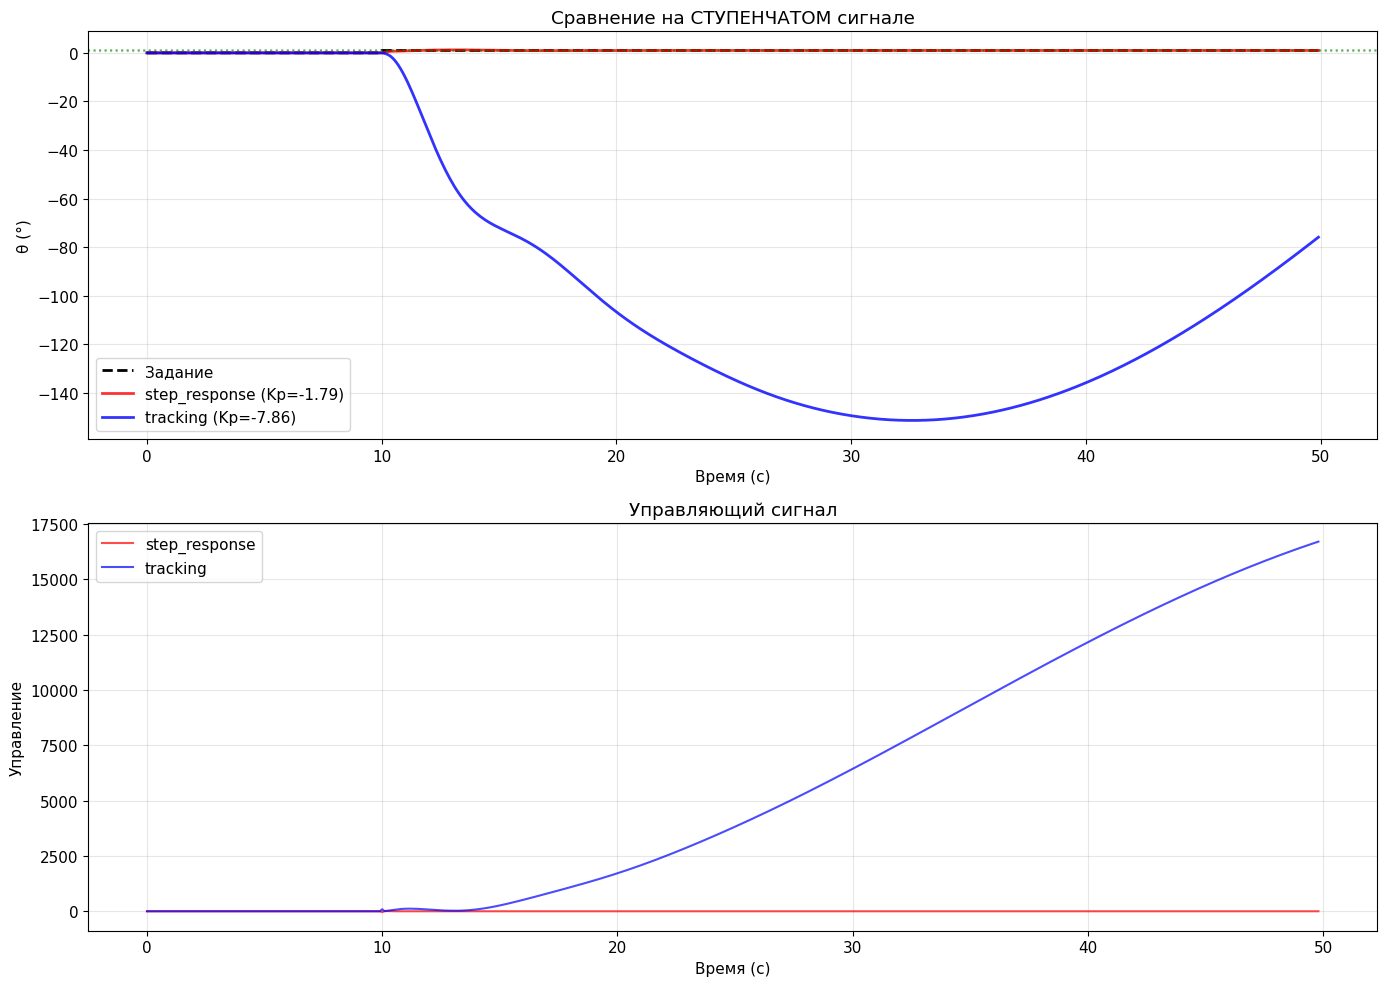

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

N_step = min(len(theta_step1_response), len(theta_step2_response), len(reference_step_deg))

ax1 = axes[0]
ax1.plot(tps[:N_step], reference_step_deg[:N_step], 'k--', linewidth=2, label='Задание')
ax1.plot(tps[:N_step], theta_step1_response[:N_step], 'r-', linewidth=2, alpha=0.8,
         label=f'step_response (Kp={pid.kp:.2f})')
ax1.plot(tps[:N_step], theta_step2_response[:N_step], 'b-', linewidth=2, alpha=0.8,
         label=f'tracking (Kp={pid_tracking.kp:.2f})')
ax1.axhline(y=step_amplitude * 0.95, color='g', linestyle=':', alpha=0.4)
ax1.axhline(y=step_amplitude * 1.05, color='g', linestyle=':', alpha=0.4)
ax1.set_xlabel('Время (с)')
ax1.set_ylabel('θ (°)')
ax1.set_title('Сравнение на СТУПЕНЧАТОМ сигнале')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(tps[:len(control_step1_history)], control_step1_history, 'r-', alpha=0.7, label='step_response')
ax2.plot(tps[:len(control_step2_history)], control_step2_history, 'b-', alpha=0.7, label='tracking')
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Управление')
ax2.set_title('Управляющий сигнал')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📈 Тесты на СИНУСОИДЕ

In [10]:
# Step Response PID на синусоиде
env_sin1 = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_sin_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

env_sin1.reset()
pid.reset()
xt_sin1 = np.array([[0.0], [0.0], [0.0], [0.0]])

for step in range(number_time_steps - 2):
    setpoint = reference_sin_deg[step]
    measurement = xt_sin1[3, 0]
    control = pid.select_action(setpoint, measurement)
    xt_sin1, _, done, _, _ = env_sin1.step(np.array([control]))
    if done: break

theta_sin1_response = env_sin1.unwrapped.model.get_state('theta', to_deg=True)

# Tracking PID на синусоиде
env_sin2 = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_sin_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

env_sin2.reset()
pid_tracking.reset()
xt_sin2 = np.array([[0.0], [0.0], [0.0], [0.0]])

for step in range(number_time_steps - 2):
    setpoint = reference_sin_deg[step]
    measurement = xt_sin2[3, 0]
    control = pid_tracking.select_action(setpoint, measurement)
    xt_sin2, _, done, _, _ = env_sin2.step(np.array([control]))
    if done: break

theta_sin2_response = env_sin2.unwrapped.model.get_state('theta', to_deg=True)

print(f"✅ Тесты на синусоиде завершены")

✅ Тесты на синусоиде завершены


## 📊 Сравнение на СИНУСОИДЕ

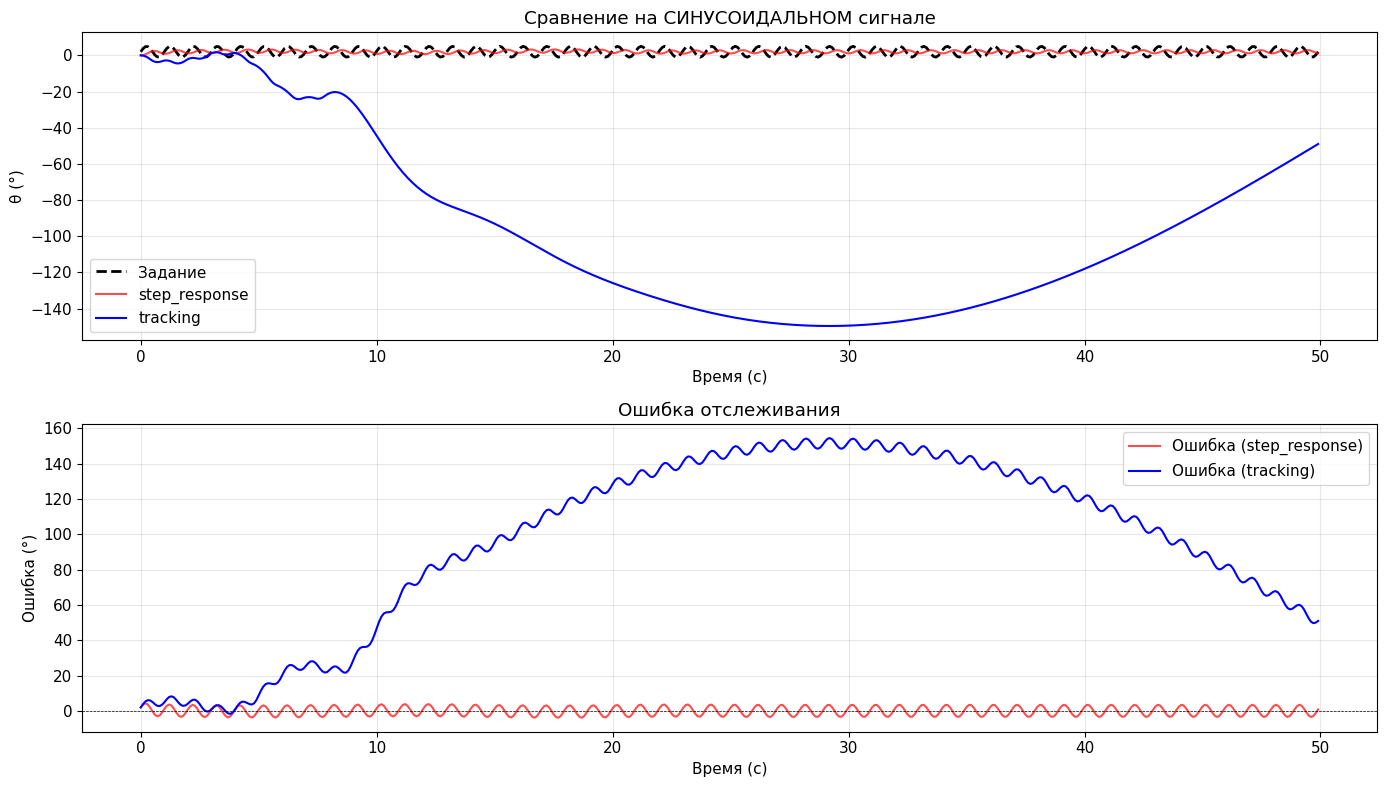

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

N_sin = min(len(theta_sin1_response), len(theta_sin2_response), len(reference_sin_deg))

ax1 = axes[0]
ax1.plot(tps[:N_sin], reference_sin_deg[:N_sin], 'k--', linewidth=2, label='Задание')
ax1.plot(tps[:N_sin], theta_sin1_response[:N_sin], 'r-', linewidth=1.5, alpha=0.7, label='step_response')
ax1.plot(tps[:N_sin], theta_sin2_response[:N_sin], 'b-', linewidth=1.5, label='tracking')
ax1.set_xlabel('Время (с)')
ax1.set_ylabel('θ (°)')
ax1.set_title('Сравнение на СИНУСОИДАЛЬНОМ сигнале')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
error_sin1 = reference_sin_deg[:N_sin] - theta_sin1_response[:N_sin]
error_sin2 = reference_sin_deg[:N_sin] - theta_sin2_response[:N_sin]
ax2.plot(tps[:N_sin], error_sin1, 'r-', alpha=0.7, label='Ошибка (step_response)')
ax2.plot(tps[:N_sin], error_sin2, 'b-', label='Ошибка (tracking)')
ax2.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Ошибка (°)')
ax2.set_title('Ошибка отслеживания')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📋 Итоговый бенчмаркинг

In [12]:
# Метрики на ступеньке
os_step1 = abs(overshoot(reference_step_deg[:N_step], theta_step1_response[:N_step]))
st_step1 = settling_time(reference_step_deg[:N_step], theta_step1_response[:N_step]) * dt
se_step1 = abs(static_error(reference_step_deg[:N_step], theta_step1_response[:N_step]))

os_step2 = abs(overshoot(reference_step_deg[:N_step], theta_step2_response[:N_step]))
st_step2 = settling_time(reference_step_deg[:N_step], theta_step2_response[:N_step]) * dt
se_step2 = abs(static_error(reference_step_deg[:N_step], theta_step2_response[:N_step]))

# Метрики на синусоиде
rmse_sin1 = np.sqrt(np.mean(error_sin1**2))
rmse_sin2 = np.sqrt(np.mean(error_sin2**2))
max_err_sin1 = np.max(np.abs(error_sin1))
max_err_sin2 = np.max(np.abs(error_sin2))

print("=" * 90)
print("📊 ИТОГОВЫЙ БЕНЧМАРКИНГ")
print("=" * 90)

print("\n🔹 Параметры PID:")
print(f"   step_response: Kp={pid.kp:.4f}, Ki={pid.ki:.4f}, Kd={pid.kd:.4f}")
print(f"   tracking:      Kp={pid_tracking.kp:.4f}, Ki={pid_tracking.ki:.4f}, Kd={pid_tracking.kd:.4f}")

print("\n" + "-" * 90)
print(f"{'Сигнал':<15} {'Метрика':<25} {'step_response':<15} {'tracking':<15} {'Лучший'}")
print("-" * 90)
print(f"{'СТУПЕНЬКА':<15} {'Overshoot (%)':<25} {os_step1:<15.2f} {os_step2:<15.2f} {'🏆 step' if os_step1 < os_step2 else '🏆 track'}")
print(f"{'':<15} {'Settling time (с)':<25} {st_step1:<15.2f} {st_step2:<15.2f} {'🏆 step' if st_step1 < st_step2 else '🏆 track'}")
print(f"{'':<15} {'Static error (°)':<25} {se_step1:<15.4f} {se_step2:<15.4f} {'🏆 step' if se_step1 < se_step2 else '🏆 track'}")
print("-" * 90)
print(f"{'СИНУСОИДА':<15} {'RMSE (°)':<25} {rmse_sin1:<15.4f} {rmse_sin2:<15.4f} {'🏆 step' if rmse_sin1 < rmse_sin2 else '🏆 track'}")
print(f"{'':<15} {'Max error (°)':<25} {max_err_sin1:<15.4f} {max_err_sin2:<15.4f} {'🏆 step' if max_err_sin1 < max_err_sin2 else '🏆 track'}")
print("-" * 90)

print("\n💡 ВЫВОД:")
print("   • mode='step_response' лучше для СТУПЕНЧАТЫХ сигналов")
print("   • mode='tracking' лучше для СИНУСОИДАЛЬНЫХ сигналов")

📊 ИТОГОВЫЙ БЕНЧМАРКИНГ

🔹 Параметры PID:
   step_response: Kp=-1.7879, Ki=-3.3842, Kd=-4.0095
   tracking:      Kp=-7.8608, Ki=3.8258, Kd=9.8577

------------------------------------------------------------------------------------------
Сигнал          Метрика                   step_response   tracking        Лучший
------------------------------------------------------------------------------------------
СТУПЕНЬКА       Overshoot (%)             24.67           100.00          🏆 step
                Settling time (с)         18.10           50.00           🏆 step
                Static error (°)          0.0025          94.4447         🏆 step
------------------------------------------------------------------------------------------
СИНУСОИДА       RMSE (°)                  2.4564          107.9926        🏆 step
                Max error (°)             4.2953          154.5683        🏆 step
------------------------------------------------------------------------------------------

💡 В